In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [3]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [5]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [21]:
print('타겟변수 :', data[15,0])
image = data[15, 1:].reshape(28,28)
image.shape

타겟변수 : 7.0


(28, 28)

In [22]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()# 개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0115121162253253213  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 63107170251252252252252250214  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 25192226226241252253202252252252252252225  0  0  0  0  0  0
  0  0  0  0  0  0  0 68223252252252252252 39 19 39 65224252252183  0  0  0  0  0  0
  0  0  0  0  0  0  0186252252252245108 53  0  0  0150252252220 2

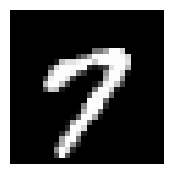

In [25]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# 칼라사진 -> 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)

In [ ]:
%pip install opencv-python==4.8.1.78

In [35]:
import cv2
# 사진이미지를 흑백포맷으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

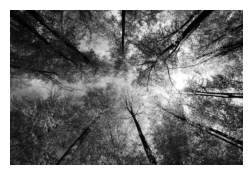

In [36]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리

In [38]:
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [42]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [44]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2


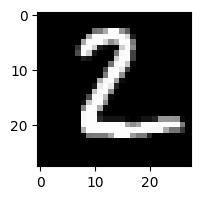

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [48]:
print(y_test[1])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [50]:
# Train데이터 6만개 => Train(5만개) + val(만개)로 분리
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [53]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [62]:
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [66]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [71]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# idx = random.sample(range(50000), 700)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]

In [73]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델 구성

In [ ]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과

model.add(Dense(units=10, activation='softmax'))